# 패키지 및 데이터

In [17]:
# ── 표준 라이브러리
from itertools import product

# ── 서드파티 라이브러리
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame, Series

# ── scikit-learn: 파이프라인 & 전처리
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── scikit-learn: 모델 선택 & 검증
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

# ── scikit-learn: 평가 지표
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# ── XGBoost 회귀 모델
from xgboost import XGBRegressor

# ── 사용자 정의 모듈
from hossam import *


In [18]:
origin = load_data("restaurant_sales_preprocessed")
origin.head()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)


,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
0,2024-01-01,16.169,122,14490,9.200,0.480,1.946,5.200,0,0
1,2024-01-02,16.005,106,11880,9.149,0.480,2.079,11.100,0,0
2,2024-01-03,16.354,120,18010,8.666,0.430,2.595,12.900,1,0
3,2024-01-04,16.082,115,11160,8.748,0.410,2.028,12.900,0,0
4,2024-01-05,16.113,124,15480,8.594,0.510,2.197,11.000,0,0


### 카테고리로 dtype 변환

In [21]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("int")
origin["weekend"] = origin["weekend"].astype("int")
origin.info()



어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales           353 non-null    float64
 1   visitors        353 non-null    int64  
 2   avg_price       353 non-null    int64  
 3   marketing_cost  353 non-null    float64
 4   delivery_ratio  353 non-null    float64
 5   rain_mm         353 non-null    float64
 6   temperature     353 non-null    float64
 7   holiday         353 non-null    int32  
 8   weekend         353 non-null    int32  
dtypes: float64(5), int32(2), int64(2)
memory usage: 24.8 KB


# 훈련, 학습 데이터 분리

In [22]:
# 원본 데이터
df = origin

# 타깃 / 피처 분리
y_name = "sales"       # 예측하고 싶은 정답 변수 이름만 문자열로 지정
X = df.drop(columns=y_name) # 입력 변수 X 생성 #중요! X에서는 sales칼럼을 제거
y = df[y_name]         # 정답 변수 y 생성
  
# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52,
)

# 데이터 크기 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((264, 8), (89, 8), (264,), (89,))

🔍 이 코드가 실제로 하는 일<br>

sales를 없앤 게 아니라,<br>
X(입력)에서는 제거하고 y(정답)로 따로 분리해서<br>
Train / Test를 나눈 것입니다.

# XGBoost 모델 적합

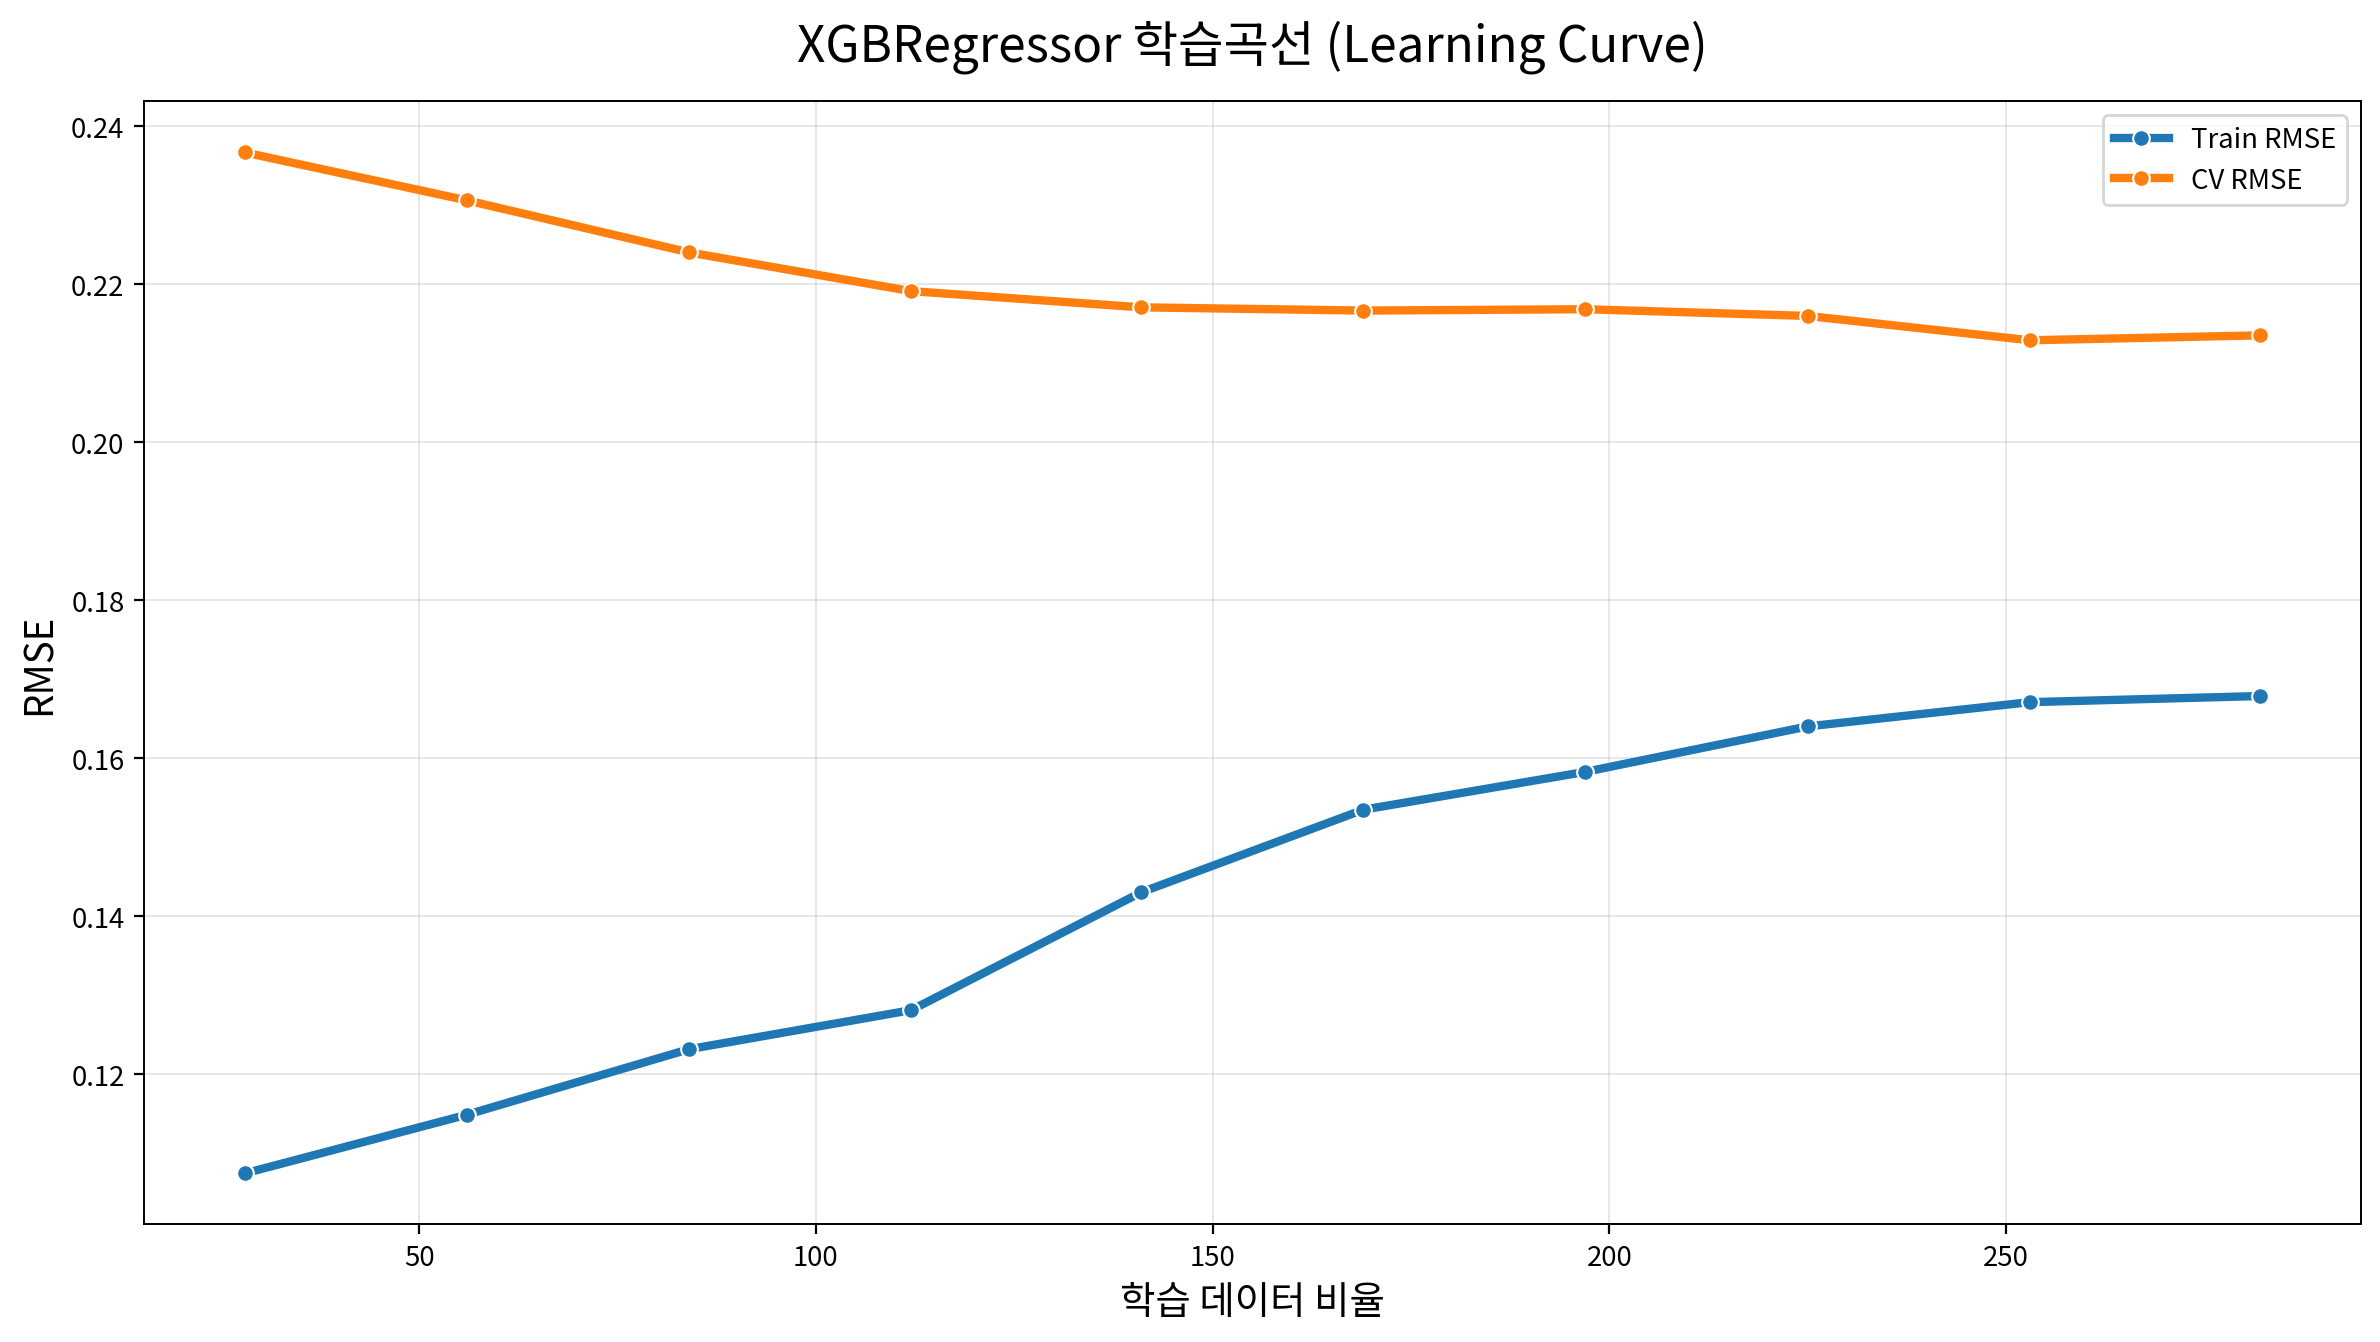

CPU times: total: 10.9 s
Wall time: 1min 50s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
XGBRegressor,0.811,0.131,0.028,0.166,0.008,-0.007,0.168,0.214,0.016,0.786,0.076,⚠️ 과대적합


In [23]:
%%time

# ── XGBoost 모델 정의
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=52,
    n_jobs=-1,
    tree_method="hist",
)

# ── 하이퍼파라미터 그리드
# 실습 상황을 고려해 탐색 범위 축소
param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

# ── GridSearchCV 설정
gs = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ── 학습
gs.fit(X_train, y_train)

# ── 최적 모델
best_model = gs.best_estimator_

# ── 성능 평가 + 과적합 판단
hs_get_score_cv(
    best_model,
    X_train,
    y_train,
    X,
    y,
)


### 공부

In [24]:
from xgboost import XGBRegressor

X = df.drop(columns="sales")
y = df["sales"]

reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.6,
    random_state=52
)

reg.fit(X,y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=52, ...)

 - 학습이 정상적으로 끝났다

### train/test 분리

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52
)

reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)


### n_estimators = 100으로 지정

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import pandas as pd
results = []

for seed in [0, 1, 7, 42, 52, 100]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=52
    )
    
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.01,
        max_depth=3,
        subsample=0.6,
        random_state=seed
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    r2 = r2_score(y_test, pred)
    rmse = mean_squared_error(y_test, pred, squared=False)
    
    results.append((seed, r2, rmse))

pd.DataFrame(results, columns=["random_state", "R2", "RMSE"])


c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWa

,random_state,R2,RMSE
0,0,0.555,0.252
1,1,0.550,0.254
2,7,0.552,0.253
3,42,0.557,0.252
4,52,0.552,0.253
5,100,0.555,0.252


 > learning_rate = 0.01 → 한 트리가 기여하는 양이 매우 작음

> n_estimators = 100 → 잔차를 보정하기에 트리 수가 부족

> max_depth = 3 → 표현력 제한

### n_estimators = 300으로 지정

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

results = []

for seed in [0, 1, 7, 42, 52, 100, 150, 200, 250, 300]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=52
    )
    
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.01,
        max_depth=3,
        subsample=0.6,
        random_state=seed
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    r2 = r2_score(y_test, pred)
    rmse = mean_squared_error(y_test, pred, squared=False)
    
    results.append((seed, r2, rmse))

pd.DataFrame(results, columns=["random_state", "R2", "RMSE"])


c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWa

,random_state,R2,RMSE
0,0,0.674,0.216
1,1,0.667,0.218
2,7,0.669,0.218
3,42,0.676,0.215
4,52,0.669,0.217
5,100,0.667,0.218
6,150,0.675,0.216
7,200,0.664,0.219
8,250,0.668,0.218
9,300,0.667,0.218


> 이 모델은 seed에 민감하지 않다.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

#모델정의
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.6,
    random_state=52
)

#CV설정
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=52
)

#평가지표 정의
scoring = {
    "R2": "r2",
    "RMSE": make_scorer(
        mean_squared_error,
        squared=False
    )
}

#CV실행
cv_result = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

#해석가증한 표로 정리
cv_df = pd.DataFrame({
    "Train_R2": cv_result["train_R2"],
    "CV_R2": cv_result["test_R2"],
    "Train_RMSE": cv_result["train_RMSE"],
    "CV_RMSE": cv_result["test_RMSE"],
})

cv_df

#평균 ± 변동성으로 요약
summary = cv_df.agg(["mean", "std"])
summary



ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\sklearn.py", line 1143, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\itwill\AppData\Local\Programs

### AdaBoost vs XGB

In [ ]:
# ====================================================
# 0. 라이브러리
# ====================================================
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error
from xgboost import XGBRegressor
import pandas as pd

# ====================================================
# 1. 데이터 준비
# ====================================================
# target 분리
X = df.drop(columns="sales")
y = df["sales"]

# 🔑 XGBoost용 One-Hot Encoding (category 처리)
X_encoded = pd.get_dummies(
    X,
    columns=["holiday", "weekend"],
    drop_first=True
)

# (확인용)
print(X_encoded.dtypes)

# ====================================================
# 2. 모델 정의
# ====================================================
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.6,
    random_state=52
)

# ====================================================
# 3. CV 설정
# ====================================================
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=52
)

# ====================================================
# 4. 평가 지표
# ====================================================
scoring = {
    "R2": "r2",
    "RMSE": make_scorer(mean_squared_error, squared=False)
}

# ====================================================
# 5. CV 실행
# ====================================================
cv_result = cross_validate(
    model,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# ====================================================
# 6. 결과 정리
# ====================================================
cv_df = pd.DataFrame({
    "Train_R2": cv_result["train_R2"],
    "CV_R2": cv_result["test_R2"],
    "Train_RMSE": cv_result["train_RMSE"],
    "CV_RMSE": cv_result["test_RMSE"],
})

cv_df

# ====================================================
# 7. 평균 ± 표준편차 요약
# ====================================================
summary = cv_df.agg(["mean", "std"])
summary


visitors            int64
avg_price           int64
marketing_cost    float64
delivery_ratio    float64
rain_mm           float64
temperature       float64
holiday_1            bool
weekend_1            bool
dtype: object


c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWa

,Train_R2,CV_R2,Train_RMSE,CV_RMSE
mean,0.812,0.666,0.165,0.215
std,0.011,0.078,0.002,0.012


In [ ]:
X.dtypes

visitors             int64
avg_price            int64
marketing_cost     float64
delivery_ratio     float64
rain_mm            float64
temperature        float64
holiday           category
weekend           category
dtype: object

In [ ]:
X_train.dtypes

visitors             int64
avg_price            int64
marketing_cost     float64
delivery_ratio     float64
rain_mm            float64
temperature        float64
holiday           category
weekend           category
dtype: object

In [1]:
X_test.dtypes

NameError: name 'X_test' is not defined

In [2]:
import pandas as pd

# -------------------------
# 일반 리스트 데이터
# -------------------------
data = {
    "name": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "age": [23, 25, 22, 28, 35, 31, 29, 24],
    "salary": [3200, 3500, 3000, 4200, 5200, 4800, 4100, 3300],
    "department": ["IT", "IT", "HR", "HR", "Sales", "Sales", "IT", "HR"],
    "experience": [1, 3, 0, 4, 7, 6, 5, 2],
    "remote": [True, False, True, False, False, True, True, False],
}

# -------------------------
# 데이터프레임 생성
# -------------------------
df = pd.DataFrame(data)

df


,name,age,salary,department,experience,remote
0,A,23,3200,IT,1,True
1,B,25,3500,IT,3,False
2,C,22,3000,HR,0,True
3,D,28,4200,HR,4,False
4,E,35,5200,Sales,7,False
5,F,31,4800,Sales,6,True
6,G,29,4100,IT,5,True
7,H,24,3300,HR,2,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        8 non-null      object
 1   age         8 non-null      int64 
 2   salary      8 non-null      int64 
 3   department  8 non-null      object
 4   experience  8 non-null      int64 
 5   remote      8 non-null      bool  
dtypes: bool(1), int64(3), object(2)
memory usage: 460.0+ bytes


In [14]:
df["name"] = df["name"].astype("object")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        8 non-null      object
 1   age         8 non-null      int64 
 2   salary      8 non-null      int64 
 3   department  8 non-null      object
 4   experience  8 non-null      int64 
 5   remote      8 non-null      bool  
dtypes: bool(1), int64(3), object(2)
memory usage: 460.0+ bytes


In [15]:
df.describe()

,age,salary,experience
count,8.000,8.000,8.000
mean,27.125,3912.500,3.500
std,4.454,797.205,2.449
min,22.000,3000.000,0.000
25%,23.750,3275.000,1.750
50%,26.500,3800.000,3.500
75%,29.500,4350.000,5.250
max,35.000,5200.000,7.000


In [22]:
# salary기준으로 행 전체 정렬
df.sort_values("salary", ascending=False)

,name,age,salary,department,experience,remote
4,E,35,5200,Sales,7,False
5,F,31,4800,Sales,6,True
3,D,28,4200,HR,4,False
6,G,29,4100,IT,5,True
1,B,25,3500,IT,3,False
7,H,24,3300,HR,2,False
0,A,23,3200,IT,1,True
2,C,22,3000,HR,0,True


In [ ]:
# 부서별로 묶고 같은 부서 안에서는 연봉 높은 순
df.sort_values(["department","salary"], ascending=[True, False])

,name,age,salary,department,experience,remote
3,D,28,4200,HR,4,False
7,H,24,3300,HR,2,False
2,C,22,3000,HR,0,True
6,G,29,4100,IT,5,True
1,B,25,3500,IT,3,False
0,A,23,3200,IT,1,True
4,E,35,5200,Sales,7,False
5,F,31,4800,Sales,6,True


In [25]:
# 사람별 데이터
# [나이, 연봉, 경력, 재택근무]
X = np.array([
    [23, 3200, 1, 1],
    [25, 3500, 3, 0],
    [22, 3000, 0, 1],
    [28, 4200, 4, 0],
    [35, 5200, 7, 0],
    [31, 4800, 6, 1],
    [29, 4100, 5, 1],
    [24, 3300, 2, 0],
    [27, 3900, 3, 1],
    [33, 5000, 8, 0],
])

# 컬럼 의미
# 0: age, 1: salary, 2: experience, 3: remote


In [27]:
import numpy as np

age = np.array([23, 25, 22, 28])
salary = np.array([3200, 3500, 3000, 4200])
exp = np.array([1, 3, 0, 4])


In [28]:
for a,s,e in zip(age,salary,exp):
    print(f"나이={a}, 연봉={s}, 경력={e}")
    

나이=23, 연봉=3200, 경력=1
나이=25, 연봉=3500, 경력=3
나이=22, 연봉=3000, 경력=0
나이=28, 연봉=4200, 경력=4


# numpy, pandas 연습

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
# 난수 고정

# NumPy 데이터 생성
data = np.column_stack([
    np.random.normal(50, 10, 100),     # score  # 평균:50, 표준편차:10, 데이터 100
    np.random.normal(170, 7, 100),     # height
    np.random.randint(20, 60, 100),    # age
    np.random.randint(0, 2, 100)       # passed (0/1)
])

# np.random.normal(평균,표준편차, 개수)


# DataFrame 변환
df = pd.DataFrame(
    data,
    columns=["score", "height", "age", "passed"]
)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   score   100 non-null    float64
 1   height  100 non-null    float64
 2   age     100 non-null    float64
 3   passed  100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


### score의 평균과 중앙값을 구하라
### age의 최댓값과 최솟값 차이를 구하라

In [9]:
df["score"].mean()
df["age"].median()

df["age"].max() - df["age"].min()

39.0

### score가 60이상인 사람만 추출하라
### passe == 1이면서 age >=30인 데이터의 개수는?

In [16]:
df[df["score"] >= 60]

df[(df["passed"]==1)&(df["age"]>30)].shape[0]

40

### 파생변수 생성

In [18]:
df["pseudo_bmi"] = df["score"]/(df["height"] / 100) ** 2
df.head()


,score,height,age,passed,pseudo_bmi
0,54.967,160.092,21.000,1.000,21.447
1,48.617,167.055,45.000,1.000,17.421
2,56.477,167.601,36.000,0.000,20.106
3,65.230,164.384,59.000,1.000,24.140
4,47.658,168.871,52.000,0.000,16.712


### 상관관계 분석

In [19]:
corr = df.corr()
corr["score"].sort_values(ascending=False)

score         1.000
pseudo_bmi    0.928
passed        0.042
age          -0.095
height       -0.136
Name: score, dtype: float64

### pandas 데이터프레임으로 변경

In [8]:
df = pd.DataFrame(
    data,
    columns=["score", "height", "age", "passed"]
)
df.head()
df.describe()

,score,height,age,passed
count,100.000,100.000,100.000,100.000
mean,48.962,170.156,40.610,0.480
std,9.082,6.676,11.578,0.502
min,23.803,156.569,20.000,0.000
25%,43.991,164.360,31.000,0.000
50%,48.730,170.589,42.000,0.000
75%,54.060,173.767,50.250,1.000
max,68.523,189.041,59.000,1.000


### 실습

In [ ]:
np.random.seed(0)

arr = np.random.randint(10, size=2,2)
#  2*2짜리 RANDOM ARRAY 생성

print(arr)

df1 = pd.DataFrame(arr, copy=False)
df2 = pd.DataFrame(arr, copy=True)

<!-- ###  -->